### 1.Import Libraries and Load Data

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Ahmed Almoor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.Clean Data

In [2]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['salary_year_avg'].notna())].copy()

df_DA['job_skills'] = df_DA['job_skills'].apply(lambda x: x if isinstance(x, list) else [])
df_DA_exploded = df_DA.explode('job_skills')

### 3. Calculate Percent of Job Postings That Have Skills

In [3]:
df_DA_skills = (
    df_DA_exploded.groupby('job_skills')
    .agg({'salary_year_avg': ['count', 'median']})
)
df_DA_skills.columns = ['skill_count', 'median_salary']
df_DA_skills = df_DA_skills.sort_values(by='skill_count', ascending=False).reset_index()

job_total = len(df_DA)
df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / job_total) * 100

### 4. Median Salary vs Perfect Skill Demand

In [4]:
skill_limit = 5

df_DA_skills_high_demand = df_DA_skills[
    (df_DA_skills['skill_percent'] >= skill_limit)
]

### 5. Plot Optimal Skills for Data Analysts

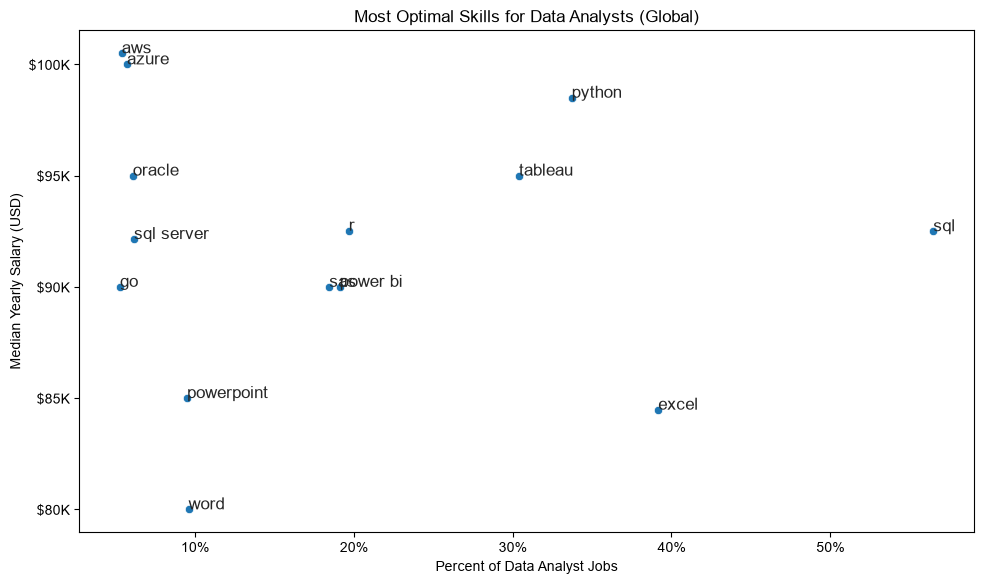

In [5]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_DA_skills_high_demand,
    x='skill_percent',
    y='median_salary',
    ax=ax
)

sns.set_theme(style='ticks')

ax.set_title('Most Optimal Skills for Data Analysts (Global)')
ax.set_ylabel('Median Yearly Salary (USD)')
ax.set_xlabel('Percent of Data Analyst Jobs')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

for i, txt in enumerate(df_DA_skills_high_demand['job_skills']):
    ax.annotate(
        txt,
        (df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i])
    )

plt.tight_layout()
plt.show()